In [1]:
import os
import sys
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))  # repo root (mac/linux)
sys.path.append(parent_dir)
from producting_Wdf_core import *
#defining the model parameters
# modelpar={
#     "M":9.38,
#     "m_omega":7.83,
#     "m_rho":7.70,
#     "m_sigma":5.3377,
#     "g_omega":11.3899,
#     "g_sigma":9.6530,
#     "g_rho":3.2411,
#     "g2":-18.1900,
#     "g3":4.1839,
#     "c3":74.1039,
#     "electronmass":0.00511,
#     "echarge":0.303
# }
#parameters form the AI Paper
modelpar={
    "M":9.38,
    "m_omega":7.83,
    "m_rho":7.70,
    "m_sigma":5.31,
    "g_omega":11.8,
    "g_sigma":9.82,
    "g_rho":3.42,
    "g2":-15.5,
    "g3":1.26,
    "c3":72.6,
    "electronmass":0.00511,
    "echarge":0.303
}


/home/guolj/.local/lib/python3.10/site-packages/torch/__init__.py:690: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:451.)
  _C._set_default_tensor_type(t)


In [2]:
#define model and test
device='cuda:0' if torch.cuda.is_available() else 'cpu'  # auto: GPU on Linux, CPU on Mac
rho_p=(torch.ones(1000)*0.1).to(torch.device(device))
rho_n=(torch.ones(1000)*0.1).to(torch.device(device))
netwdf=rmftorch(modelpar,rho_p,rho_n,bn_n=6,bn_p=6,grid_corer=5,grid_maxr=1000,device=device).to(torch.device(device))
params = [
    {"params": netwdf.rho_n_rato, "lr": 0.1}, 
    {"params": netwdf.rho_p_rato, "lr": 0.1},
    # {"params": netwdf.grid_corer, "lr": 0.001}    
]

optm=optim.Adam(params, lr=0.1)
scheduler=torch.optim.lr_scheduler.ExponentialLR(optm, 0.9,last_epoch=-1)
bn,bp=netwdf.baryons()
initbaryons=(bn+bp).detach()
# for e in netwdf.parameters():
#     print(e)

netwdf.energy_core(step=0.008)

/home/guolj/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


tensor(112.5599, device='cuda:0', grad_fn=<SumBackward0>)

In [3]:
#load the model if saved
map_location=torch.device(device)
netwdf.load_state_dict(torch.load("results/parameter/C12_model_par",map_location=map_location))
optm=optim.Adam(netwdf.parameters(), lr=0.0)

In [91]:
optm=optim.Adam(netwdf.parameters(), lr=0.05)

In [4]:
#进行迭代
# optm=optim.Adam(params, lr=0.00001)
for i in range(1):
    for j in range(1):
        optm.zero_grad()
        lossf=nn.MSELoss()
        eps=netwdf.energy_core(step=0.008)
        # eps,h=netwdf.findsigma(accuracy=4,step=0.01)
        bn,bp=netwdf.baryons()
        loss=lossf(eps,torch.zeros(eps.size()).to(torch.device(device)))#+lossf(bn,initbn*torch.ones(bn.size()).to(torch.device('cuda:0')))*1000+lossf(bp,initbp*torch.ones(bp.size()).to(torch.device('cuda:0')))*1000
        resulte=eps.detach().cpu().numpy()
        #计算原子核测量半径
        maxgridrcore=netwdf.grid_corer.detach().cpu().numpy()
        raduis=np.linspace(0.05,maxgridrcore,netwdf.pn_grid_num)
        rx=np.diff(raduis**3)*4/3*np.pi
        rhoresult=(netwdf.rho_n().detach().cpu().numpy()+netwdf.rho_p().detach().cpu().numpy())/initbaryons.cpu().numpy()
        ry=(2*rhoresult[1:]-np.diff(rhoresult))/2
        r_2=raduis
        realradius=np.sum(((2*r_2[1:]-np.diff(r_2))/2)**2*ry*rx)**0.5*1.97
        print('iter:{:.0f},'.format(i*50+j),\
              'core_energy:{:.6f} Hmev'.format(resulte),\
              'BindingEnergy:{:.6f} Mev'.format(938-resulte*100/initbaryons.cpu().numpy()),\
              'baryons:{:.2f},{:.2f}'.format(bn.detach().cpu().numpy(),bp.detach().cpu().numpy()),\
              'MeanCoreRadius:{:.4f}'.format(realradius),\
                'Setcorer:{:.2f}'.format(netwdf.grid_corer*1.97),\
                    'loss:{:.6f}'.format(loss.detach().cpu().numpy()))
        loss.backward()
        optm.step()
        netwdf.updategrid()
        #print("rho",netwdf.rho_n.detach().cpu().numpy())
        #print(epsr)
    scheduler.step() 
    

iter:0, core_energy:111.733899 Hmev BindingEnergy:6.884178 Mev baryons:6.00,6.00 MeanCoreRadius:2.2443 Setcorer:5.00 loss:12484.464118


/home/guolj/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:143: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "


In [ ]:
from tqdm import tqdm
#计算平均场下的eos
device='cuda:0' if torch.cuda.is_available() else 'cpu'  # auto: GPU on Linux, CPU on Mac

rho_p=(torch.ones(20)*0.1*1.97*1.97*1.97).to(torch.device(device))
rho_n=(torch.ones(20)*0.1*1.97*1.97*1.97).to(torch.device(device))
grid_corer=2
rhonum=20
rho=torch.linspace(0.01,0.32,rhonum)
epsres=torch.zeros(rhonum)
sigma=torch.zeros(rhonum)
partialsigma=torch.zeros(rhonum)
netwdf=rmftorch(modelpar,rho_p=rho_p,rho_n=rho_n,bn_n=0,bn_p=0,grid_corer=grid_corer,grid_maxr=1000,device=device).to(torch.device(device))
core_V=((grid_corer)**3*4*np.pi/3)
rho_b=torch.zeros(rhonum)
for i in tqdm(range(rhonum),desc='caluing'):
    rho_nn=rho[i]
    rho_pp=rho[i]
    bn_n=rho_nn*core_V
    bn_p=rho_pp*core_V
    netwdf.bn_n=bn_n
    netwdf.bn_p=bn_p
    rho_b[i]=netwdf.rho_p()[10]+netwdf.rho_n()[10]
    # print(str(rho_nn.detach().numpy())+":"+str(netwdf.rho_n()[0]/1.97**3))
    # print(str(rho_pp.detach().numpy())+":"+str(netwdf.rho_p()[0]))
    a,b=netwdf.findsigma(step=0.01)
    sigma[i]=a[10]*100
    epsres[i]=netwdf.eps_core(step=0.01)[10]*100

print(epsres)
plt.plot(rho_b.cpu().detach().numpy()/1.97**3,epsres.cpu().detach().numpy()/1.97/1.97/1.97/(rho_b.cpu().detach().numpy()/1.97**3)-938)

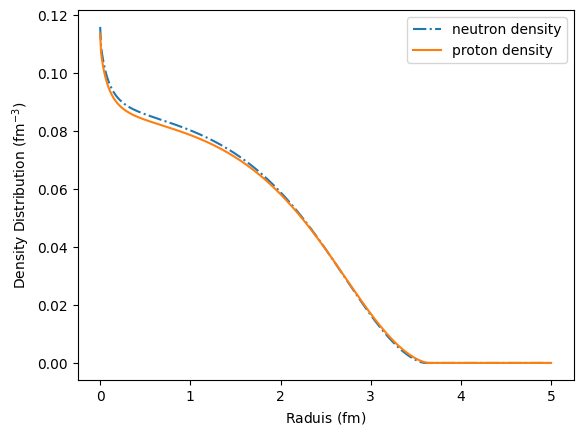

In [5]:
#画图
# print(netwdf.rho_n())
maxgridrcore=netwdf.grid_corer.detach().cpu().numpy()*1.97
raduis=np.linspace(0,maxgridrcore,netwdf.pn_grid_num)
startingpoint=0
plt.plot(raduis[startingpoint:],(netwdf.rho_n().detach().cpu().numpy()/1.97**3)[startingpoint:],'-.',label="neutron density")
plt.plot(raduis[startingpoint:],(netwdf.rho_p().detach().cpu().numpy()/1.97**3)[startingpoint:],'-',label="proton density")
resulte=eps.detach().cpu().numpy()
# name="Density distribution at gridcorer={:.2f} fm with E={:.6f} (HMev)".format(maxgridrcore,resulte)
# for i in range(5):
#     plt.plot(raduis[startingpoint+i],(netwdf.rho_n().detach().cpu().numpy()/1.97**3)[startingpoint+i],'x')
# plt.title(name)
plt.ylabel("Density Distribution ($\mathrm{fm^{-3}}$)")
plt.xlabel("Raduis ($\mathrm{fm}$)")
plt.legend()
plt.savefig("results/plots/c"+str((bn+bp).detach().cpu().numpy())+".png",dpi=500,bbox_inches = 'tight')

In [116]:
rho_n_density=np.concatenate([[raduis],[netwdf.rho_n().detach().cpu().numpy()/1.97**3]]).transpose()
rho_p_density=np.concatenate([[raduis],[netwdf.rho_p().detach().cpu().numpy()/1.97**3]]).transpose()
np.savetxt('results/density/rho_n_density_c'+str((bn+bp).detach().cpu().numpy()),rho_n_density)
np.savetxt('results/density/rho_p_density_c'+str((bn+bp).detach().cpu().numpy()),rho_p_density)

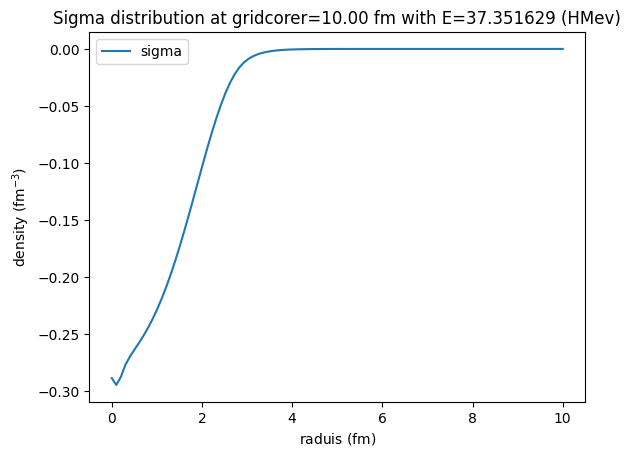

In [41]:
#画图sigma
maxgridrcore=netwdf.grid_corer.detach().cpu().numpy()*1.97
raduis=np.linspace(0,maxgridrcore,netwdf.pn_grid_num)
sigma,partialsigma=netwdf.findsigma(step=0.005)
plt.plot(raduis,sigma.detach().cpu().numpy(),label="sigma")
# plt.plot(raduis,netwdf.rho_p().detach().cpu().numpy()/1.97**3,label="proton density")
resulte=eps.detach().cpu().numpy()
# name="Sigma distribution at gridcorer={:.2f} fm with E={:.6f} (HMev)".format(maxgridrcore,resulte)
# plt.title(name)
plt.ylabel("Density Distribution ($\mathrm{fm^{-3}}$)")
plt.xlabel("Raduis ($\mathrm{fm}$)")
plt.legend()
plt.savefig("results/plots/o16.png",dpi=500,bbox_inches = 'tight')

In [6]:
#计算原子核测量半径
maxgridrcore=netwdf.grid_corer.detach().cpu().numpy()
raduis=np.linspace(0.05,maxgridrcore,netwdf.pn_grid_num)
rx=np.diff(raduis**3)*4/3*np.pi
rhoresult=(netwdf.rho_n().detach().cpu().numpy()+netwdf.rho_p().detach().cpu().numpy())/initbaryons.cpu().numpy()
ry=(2*rhoresult[1:]-np.diff(rhoresult))/2
print('归一检验:',np.sum(rx*ry))
r_2=raduis
realradius=np.sum(((2*r_2[1:]-np.diff(r_2))/2)**2*ry*rx)**0.5
print("测量半径:",realradius*1.97)
print('束缚能：{:.2f} Mev'.format(938-resulte*100/initbaryons.cpu().numpy()))

归一检验: 1.0000000000000004
测量半径: 2.24434988148946
束缚能：6.88 Mev


In [29]:
# #计算原子核测量半径
# # maxgridrcore=netwdf.grid_corer.detach().cpu().numpy()*1.97
# # raduis=np.linspace(0,maxgridrcore,netwdf.pn_grid_num)
# # rx=np.diff(raduis**3)*4/3*np.pi
# rx=(netwdf.raduisdiff_v3[:netwdf.pn_grid_num-1]*torch.pi*4/3).detach().cpu().numpy()
# rhoresult=(netwdf.rho_n().detach().cpu().numpy()+netwdf.rho_p().detach().cpu().numpy())/initbaryons.cpu().numpy()
# ry=(2*rhoresult[1:]-np.diff(rhoresult))/2
# print('归一检验:',np.sum(rx*ry))
# r_2=raduis
# realradius=np.sum(((2*r_2[1:]-np.diff(r_2))/2)**2*ry*rx)**0.5
# print("测量半径:",realradius)
# print('束缚能：{:.2f} Mev'.format(938-resulte*100/initbaryons.cpu().numpy()))

Text(0, 0.5, '$\\epsilon\\ (Mev/fm^{-3})$')

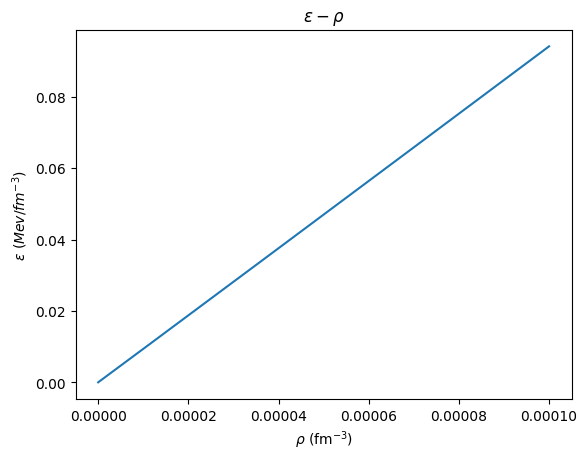

In [7]:
# rhoeos=torch.linspace(1e-11,1e-6,200000,device=device) #fm-3
rhoeos=torch.logspace(-12,-4,20000,device=device) #fm-3

# rhoeos=torch.tensor([0.1],device=device)
rr=(torch.tensor(realradius/1.97).to(torch.device(device))) 
eee,atom_num_density=netwdf.new_energy_density(rho=rhoeos*1.97*1.97*1.97,radius=rr,ener_core=resulte*1)
epseos=eee.detach().cpu().numpy()*100/1.97**3 #Mev fm-3
rhoeos=rhoeos.detach().cpu().numpy()
atom_num_density=atom_num_density.detach().cpu().numpy()
p=(rhoeos[1:]*np.diff(epseos)/np.diff(rhoeos)-epseos[1:])
# plt.plot(rhoeos[1:],p)
plt.plot(rhoeos,epseos)
plt.title("$\epsilon-\\rho$")
plt.xlabel("$\\rho\ (\mathrm{fm^{-3}})$")
plt.ylabel("$\epsilon\ (Mev/fm^{-3})$")


Text(0, 0.5, '$P\\  (Mev/fm^{-3})$')

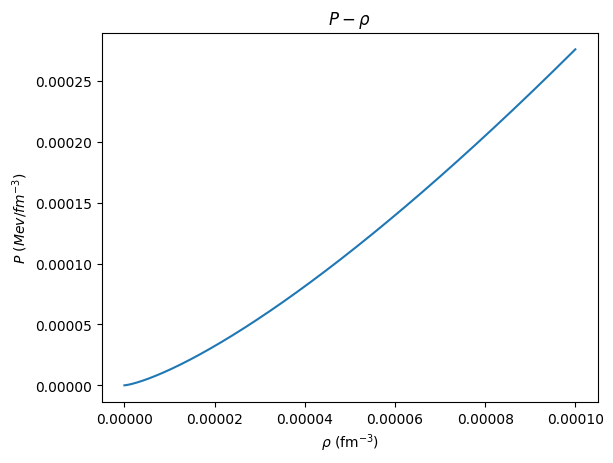

In [8]:
p=(rhoeos[1:]*np.diff(epseos)/np.diff(rhoeos)-epseos[1:])
plt.plot(rhoeos[1:],p)
plt.title("$P-\\rho$")
plt.xlabel("$\\rho \ (\mathrm{fm^{-3}})$")
plt.ylabel("$P\  (Mev/fm^{-3})$")

Text(0, 0.5, '$P\\  (Mev/fm^{-3})$')

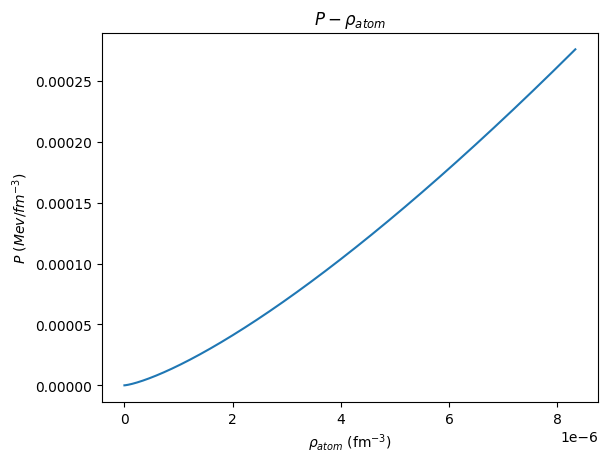

In [9]:
plt.plot(atom_num_density[1:],p)
plt.title("$P-\\rho_{atom}$")
plt.xlabel("$\\rho_{atom} \ (\mathrm{fm^{-3}})$")
plt.ylabel("$P\  (Mev/fm^{-3})$")

In [10]:
#保存结果
# torch.save(netwdf.state_dict(), "results/par/WithSigma3AndOmega4/"+name)
np.savetxt("results/eos/C12-20000-log-eos-modefiedA.txt",np.array([atom_num_density[1:],p,epseos[1:]]).transpose())

In [11]:
torch.save(netwdf.state_dict(), "results/parameter/C12_model_par")